In [3]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import cartopy.crs as ccrs
from netCDF4 import Dataset

In [4]:
grid = r"C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc"
cmaq_lon = np.array(Dataset(grid)["lon"])
cmaq_lat = np.array(Dataset(grid)["lat"])

llat, ulat = np.nanmin(cmaq_lat), np.nanmax(cmaq_lat)
llon, ulon = np.nanmin(cmaq_lon), np.nanmax(cmaq_lon)

xpad = (ulon - llon) * 0.01
ypad = (ulat - llat) * 0.01
extent_xy = [llon - xpad, ulon + xpad, llat - ypad, ulat + ypad]

print("Map extent:", extent_xy)

Map extent: [-90.13451782226562, -84.45715698242188, 40.172603149414066, 44.08426330566406]


In [7]:
base = gpd.read_file(r"C:/Users/x12la/Desktop/Scripts/LOCUS/total_onroad_emis_shapefiles/total_emis_2023_baseline_annualavg.shp").to_crs("EPSG:4326")
locus = gpd.read_file(r"C:/Users/x12la/Desktop/Scripts/LOCUS/total_onroad_emis_shapefiles/total_emis_2023_LOCUSIdling_annualavg.shp").to_crs("EPSG:4326")
hdvspatial = gpd.read_file(r"C:/Users/x12la/Desktop/Scripts/LOCUS/total_onroad_emis_shapefiles/total_emis_2023_HDVSpatial_annualavg.shp").to_crs("EPSG:4326")
locus_hdvspatial = gpd.read_file(r"C:/Users/x12la/Desktop/Scripts/LOCUS/total_onroad_emis_shapefiles/total_emis_2023_LOCUSIdlingHDVSpatial_annualavg.shp").to_crs("EPSG:4326")

In [5]:
outdir = r"C:/Users/x12la/Desktop/Scripts/LOCUS/All_TotalEmis_Figures"
os.makedirs(outdir, exist_ok=True)

In [8]:
# ============================================================
# EXCLUDE HELPER COLUMNS
# ============================================================
exclude_cols = {
    "lat", "lon", "lat_m", "lon_m", "geometry"
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def annotate_max(ax, vals, fmt="{:.2f}", color="black"):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Max: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )

def annotate_minmax(ax, vals, fmt="{:.2f}", color="black"):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vmin = float(np.min(vals)) if vals.size else np.nan
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(
        0.02, 0.02, f"Min: {fmt.format(vmin)}\nMax: {fmt.format(vmax)}",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=10, color=color,
        bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0)
    )

def annotate_panel_label(ax, label, loc="ul", fontsize=12):
    if loc == "ul":
        x, y, ha, va = -0.1, 0.99, "left", "top"
    elif loc == "ur":
        x, y, ha, va = 0.98, 0.98, "right", "top"
    else:
        raise ValueError("loc must be 'ul' or 'ur'")

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        ha=ha, va=va,
        fontsize=fontsize,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            boxstyle="round,pad=0.20",
            linewidth=0
        )
    )

def make_discrete_diff_cmap_and_norm(vmin, vmax, n_bins=9, cmap_name="bwr"):
    bounds = np.linspace(vmin, vmax, n_bins + 1)
    cmap = plt.get_cmap(cmap_name, n_bins)
    norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)
    return cmap, norm, bounds

def nice_label(col):
    mapping = {
        "NOX_peryear": "NO$_x$",
        "PM25_peryear": "PM$_{2.5}$",
        "SO2": "SO$_2$",
        "NH3": "NH$_3$",
        "NO2": "NO$_2$",
        "CH4": "CH$_4$",
        "HONO": "HONO",
        "PEC": "PEC",
        "POC": "POC",
        "PNH4": "PNH$_4$",
        "PNO3": "PNO$_3$",
        "PSO4": "PSO$_4$",
        "PMC": "PMC",
        "CO2_INV": "CO$_2$",
        "N2O_INV": "N$_2$O",
    }
    return mapping.get(col, col)

def units_label(col):
    if col.endswith("_peryear"):
        return "tons/km$^2$/year"
    else:
        return "mol/s"

def plot_gdf_column(ax, gdf, col, cmap, norm, vmin, vmax, title, ann="minmax", label=None):
    gdf.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,
        edgecolor="none",
        antialiased=False,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    ax.set_axis_off()

    vals = gdf[col].astype(float).to_numpy()
    if ann == "max":
        annotate_max(ax, vals, fmt="{:.2f}")
    else:
        annotate_minmax(ax, vals, fmt="{:.2f}")

    if label is not None:
        annotate_panel_label(ax, label)

def plot_array_panel(ax, template_gdf, arr, cmap, norm, vmin, vmax, title, ann="minmax", label=None):
    temp = template_gdf.copy()
    temp["_plotcol_"] = arr

    temp.plot(
        column="_plotcol_",
        ax=ax,
        cmap=cmap,
        norm=norm,
        edgecolor="none",
        antialiased=False,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(title, fontsize=12)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    ax.set_axis_off()

    if ann == "max":
        annotate_max(ax, arr, fmt="{:.2f}")
    else:
        annotate_minmax(ax, arr, fmt="{:.2f}")

    if label is not None:
        annotate_panel_label(ax, label)


Columns being plotted:
ACET
ACROLEIN
ALD2
ALD2_PRIMA
ALDX
APIN
BENZ
BUTADIENE1
CH4
CH4_INV
CO
CO2_INV
ETH
ETHA
ETHY
ETHYLBENZ
ETOH
FORM
FORM_PRIMA
GLY
HONO
IOLE
ISOP
IVOC
KET
MEOH
N2O_INV
NAPH
NH3
NMOG
NO
NO2
NVOL
OLE
PAL
PAR
PCA
PCL
PEC
PFE
PH2O
PK
PMC
PMG
PMN
PMOTHR
PNA
PNCOM
PNH4
PNO3
POC
PRPA
PSI
PSO4
PTI
SO2
SOAALK
TERP
TOL
UNR
VOC_INV
XYLMN


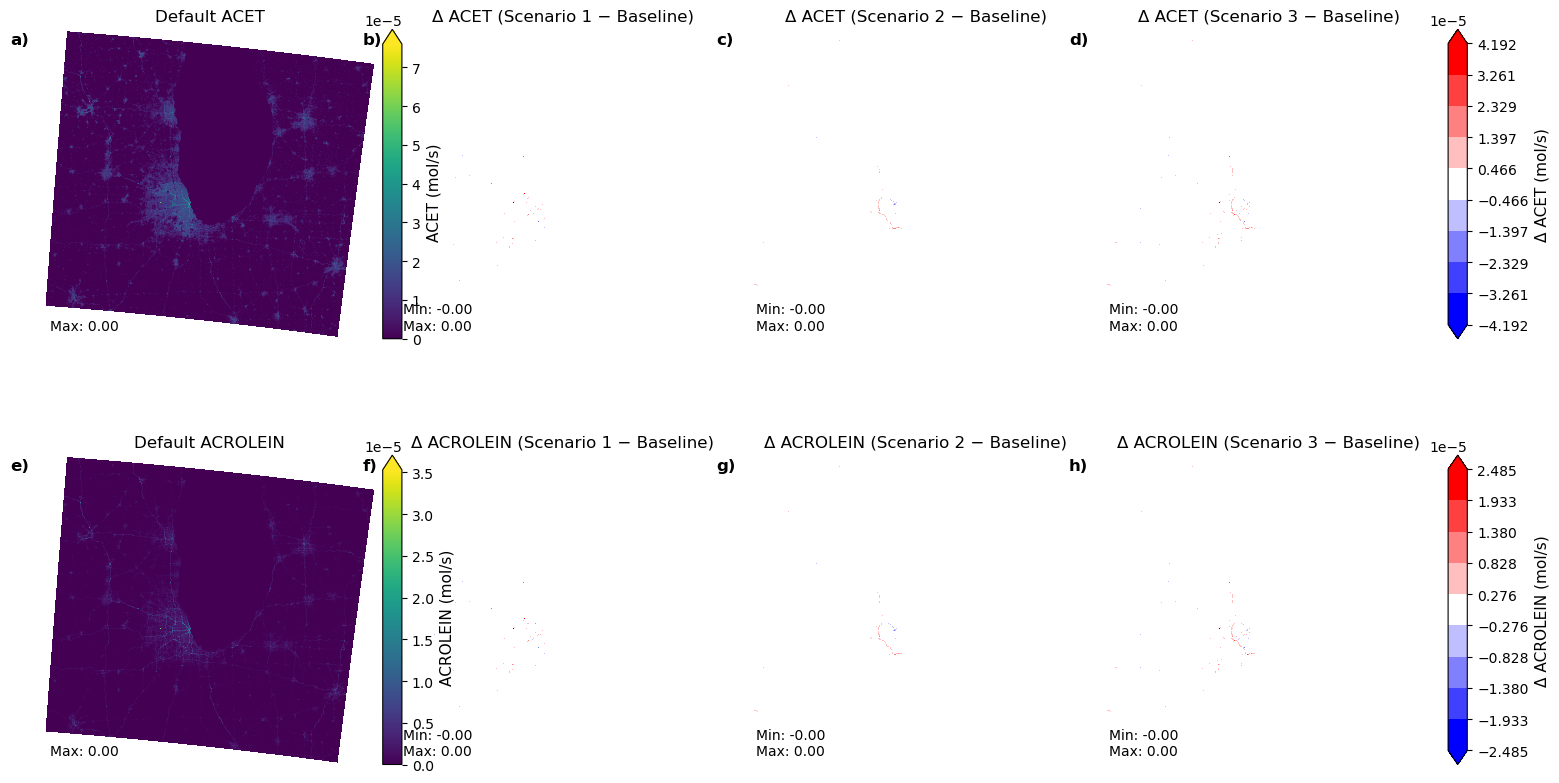

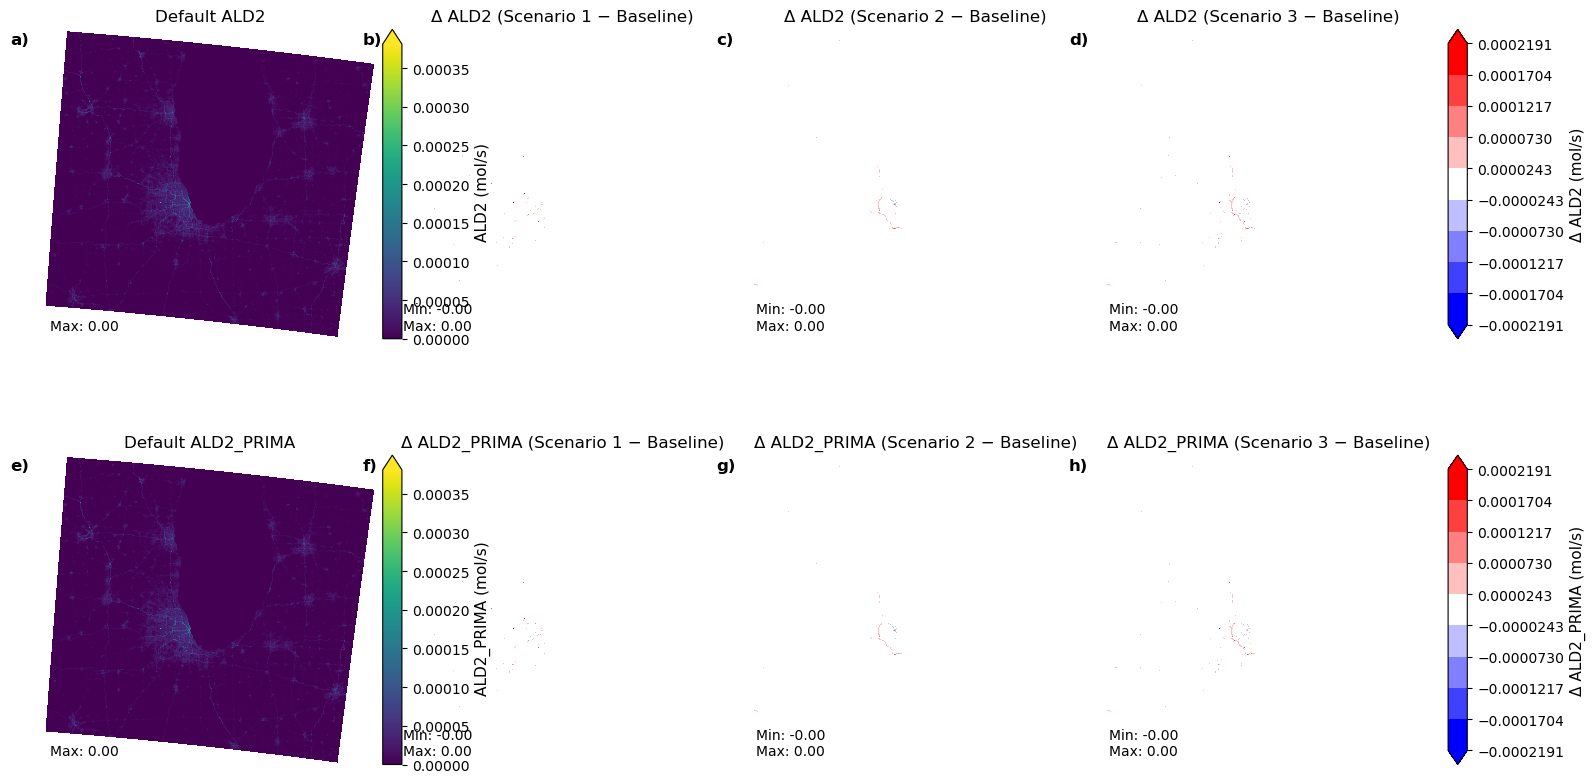

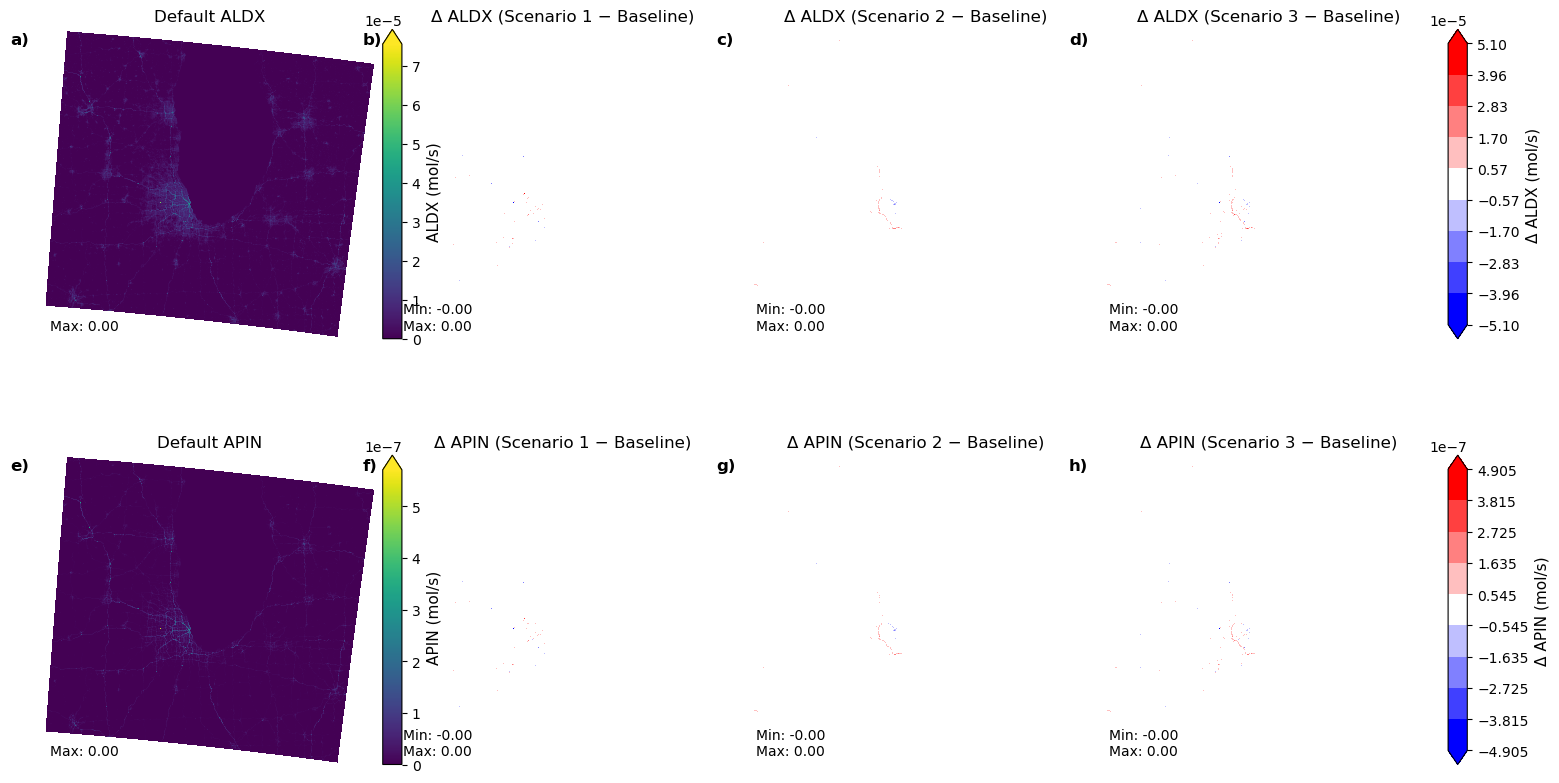

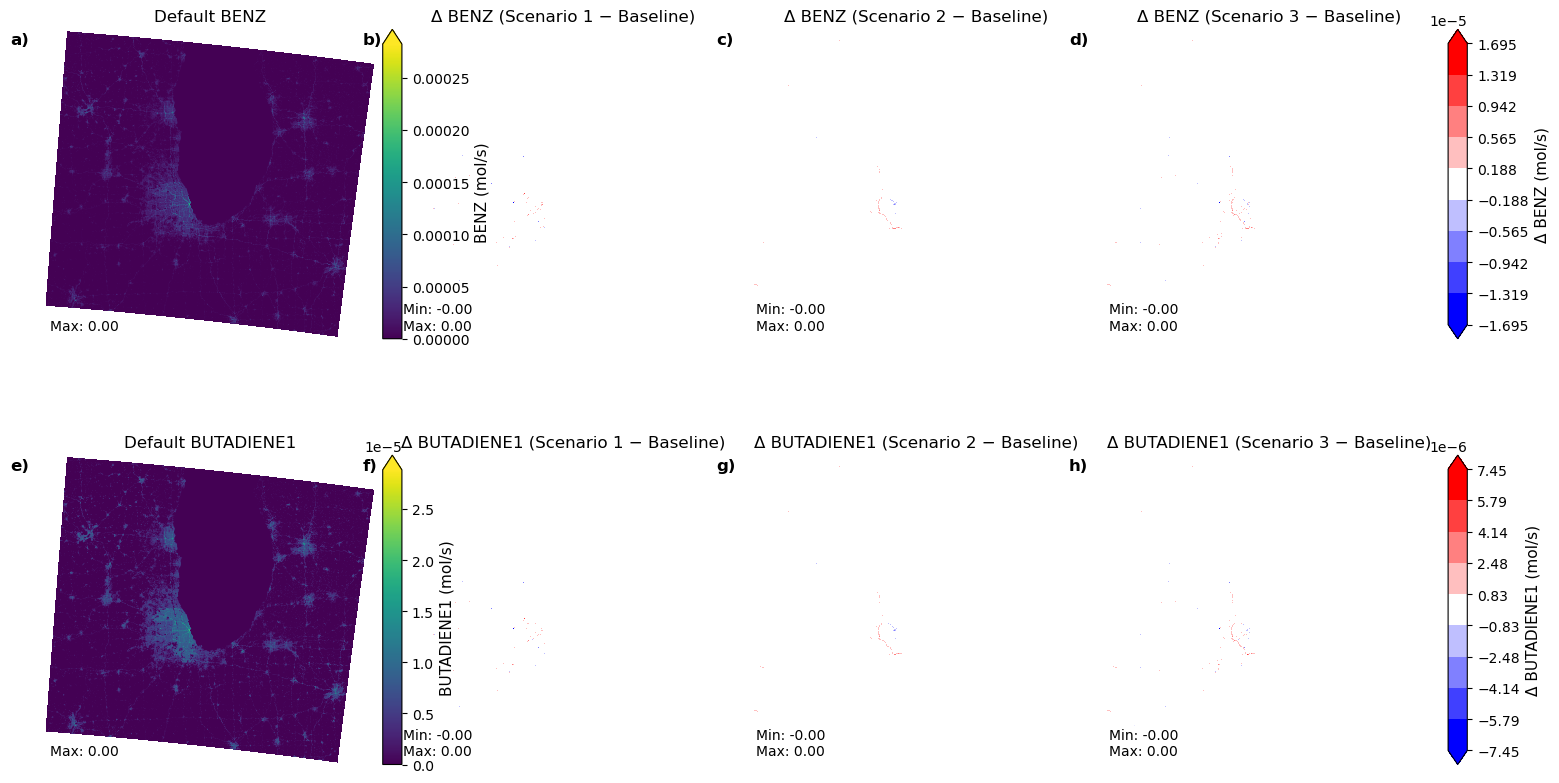

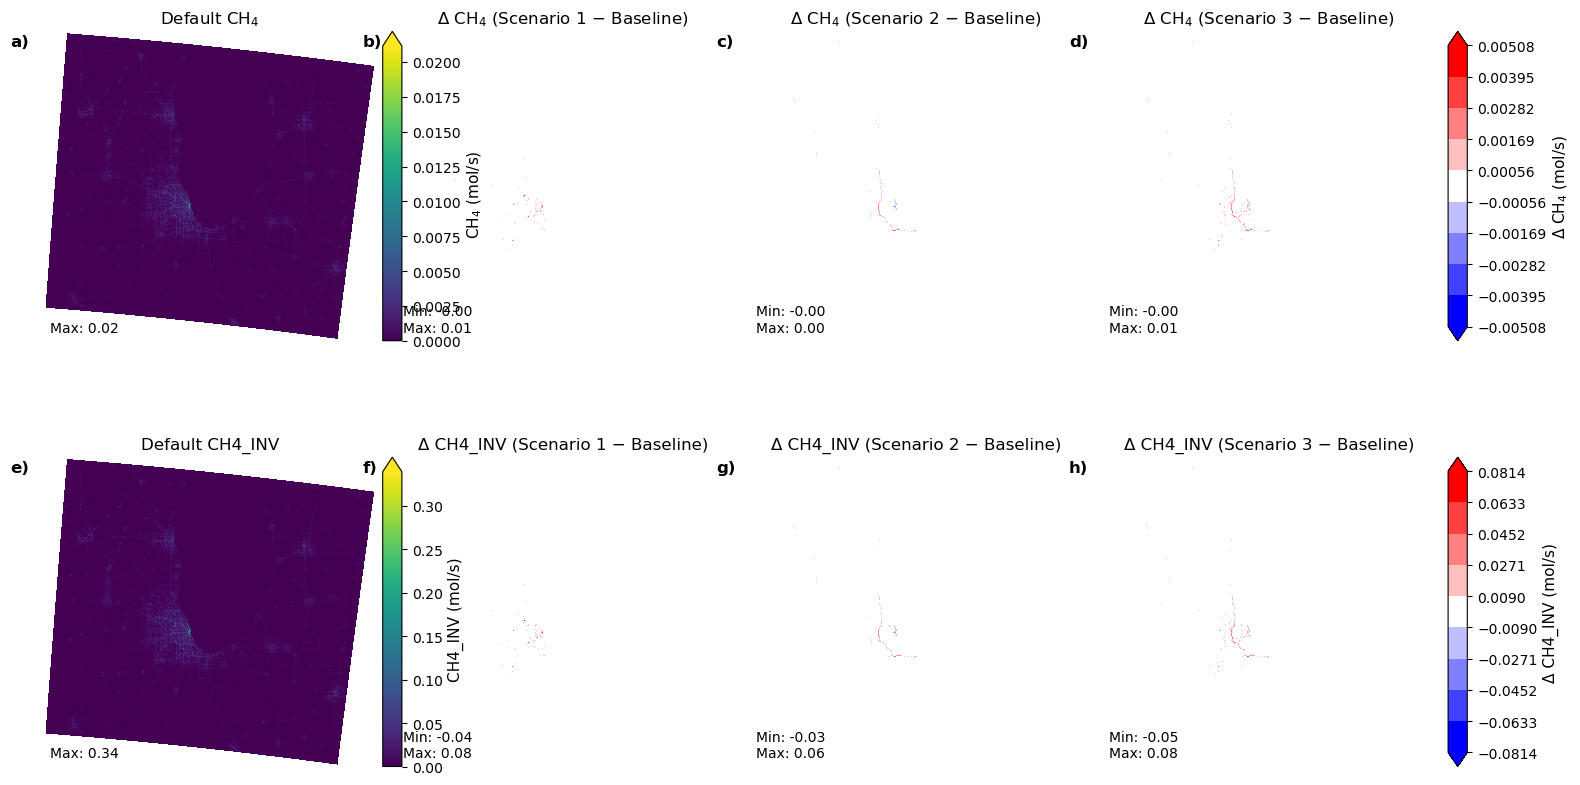

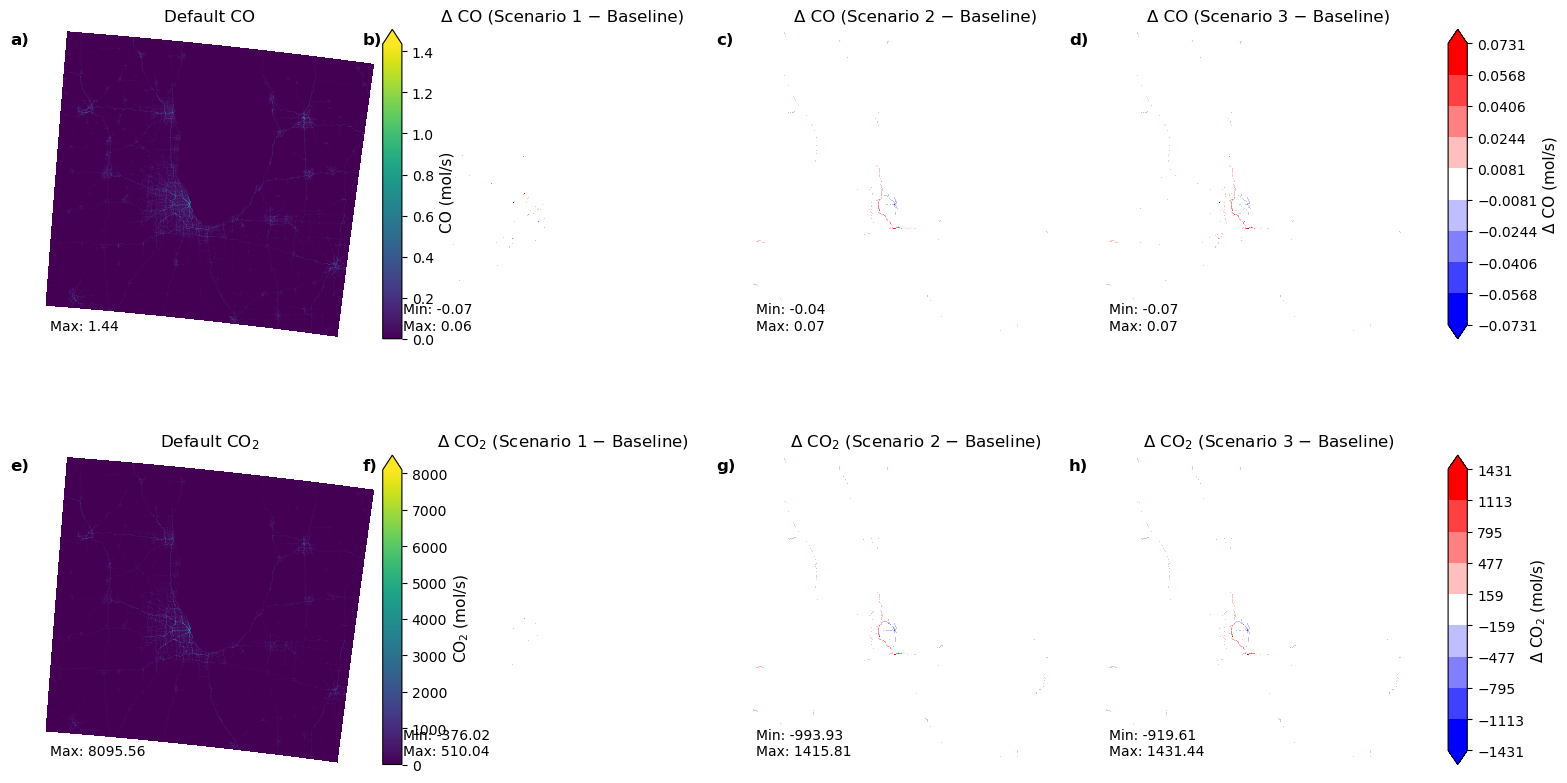

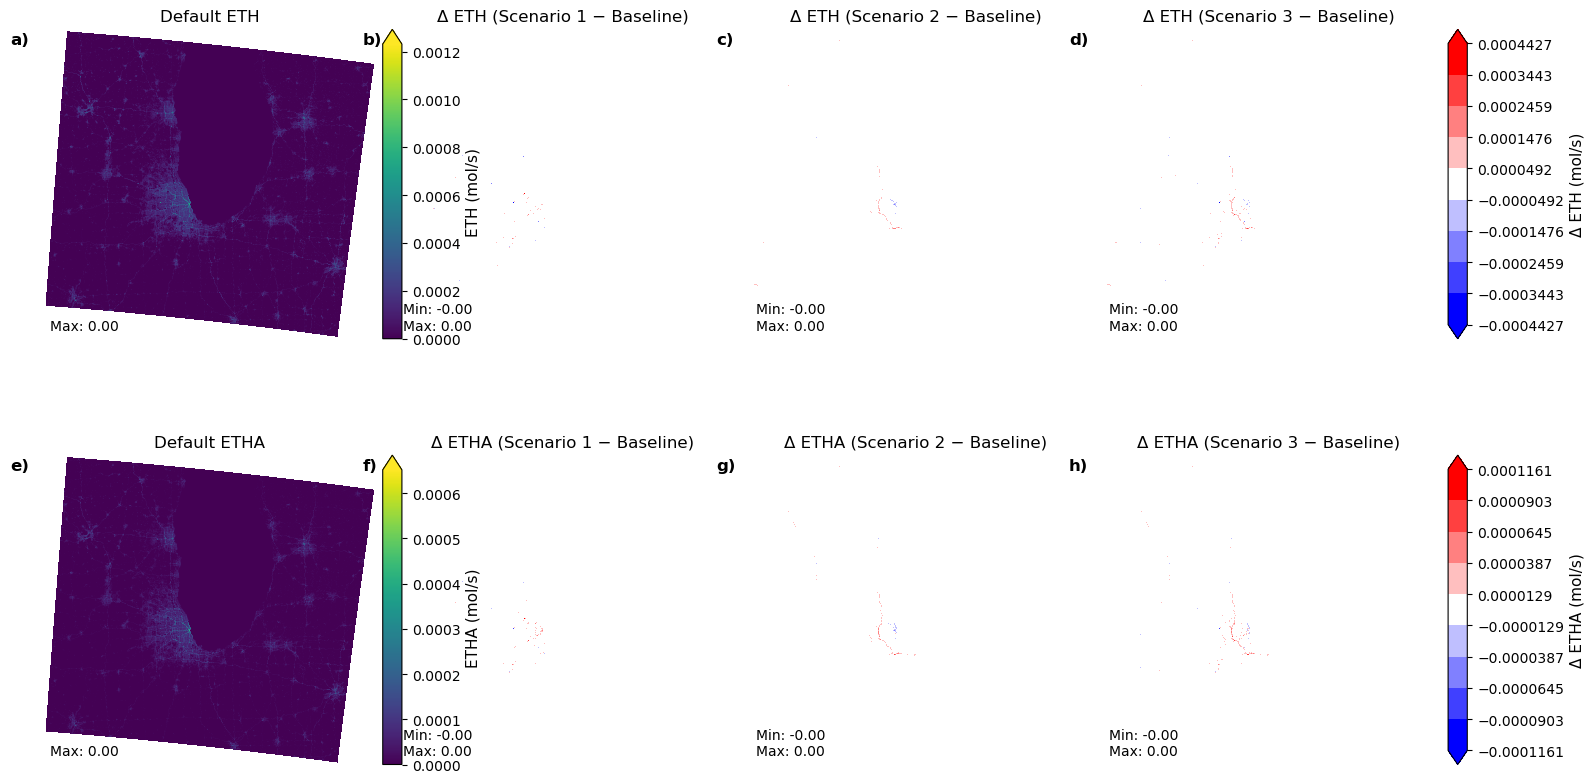

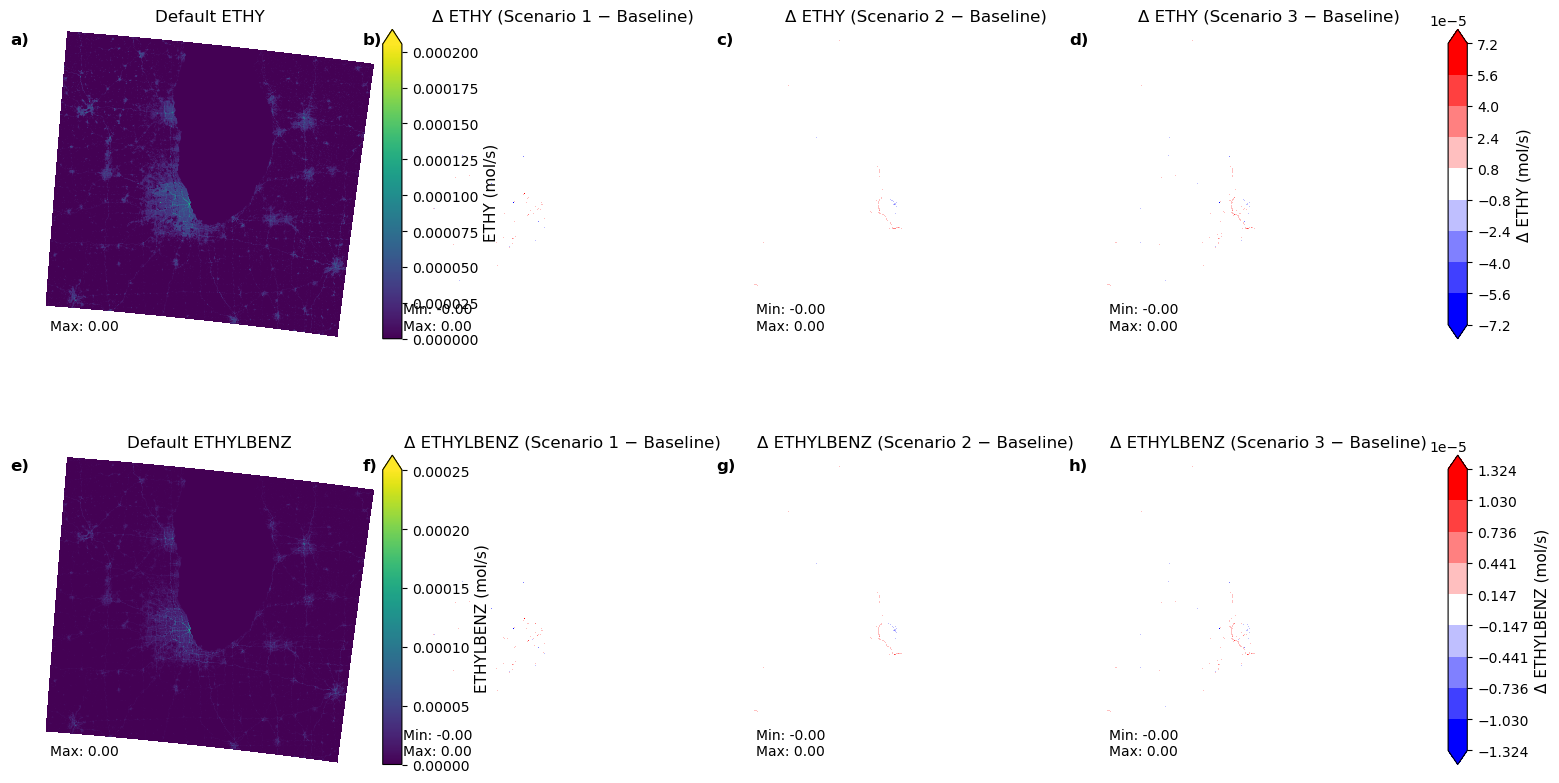

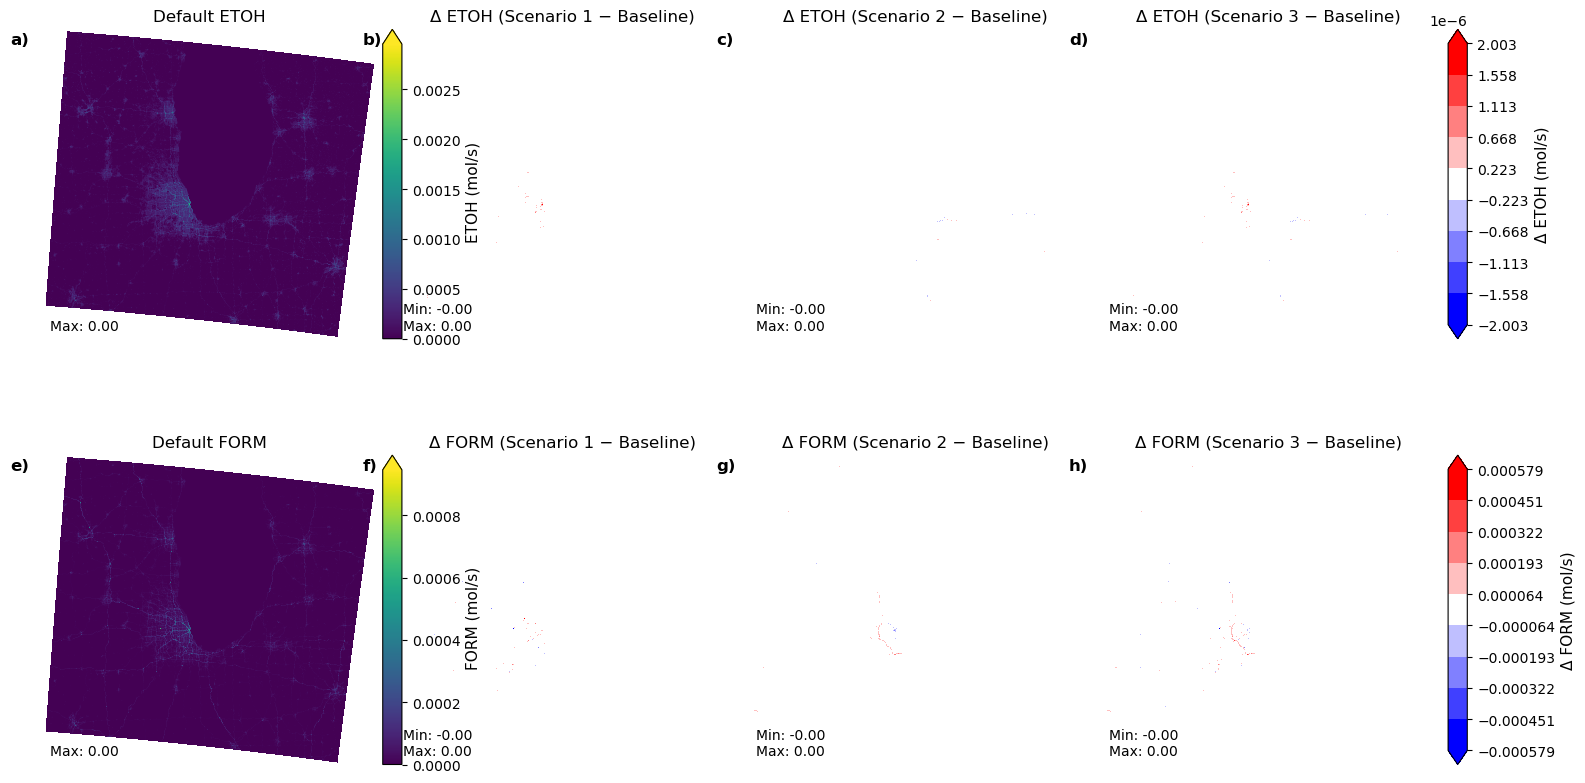

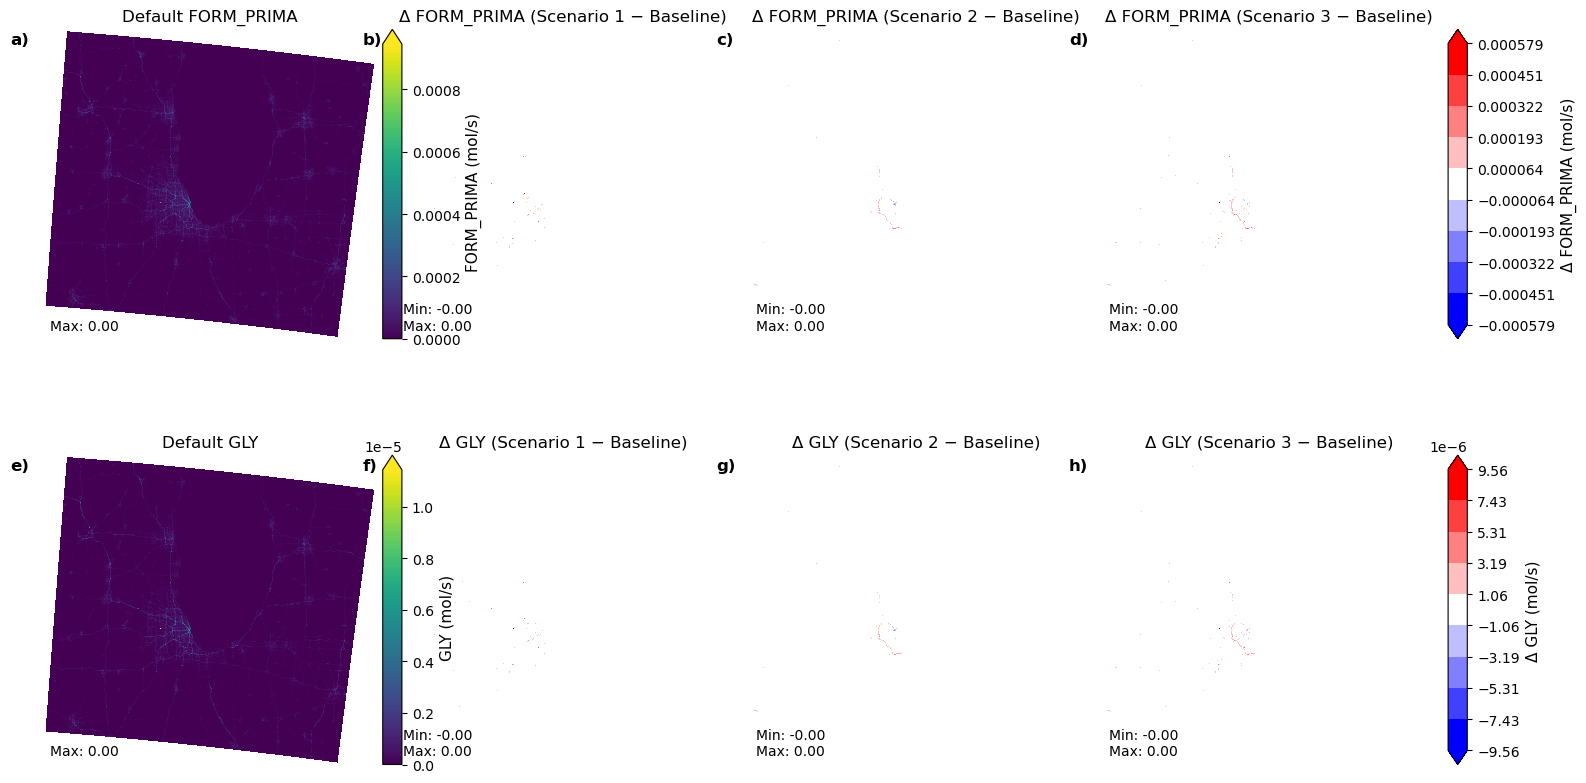

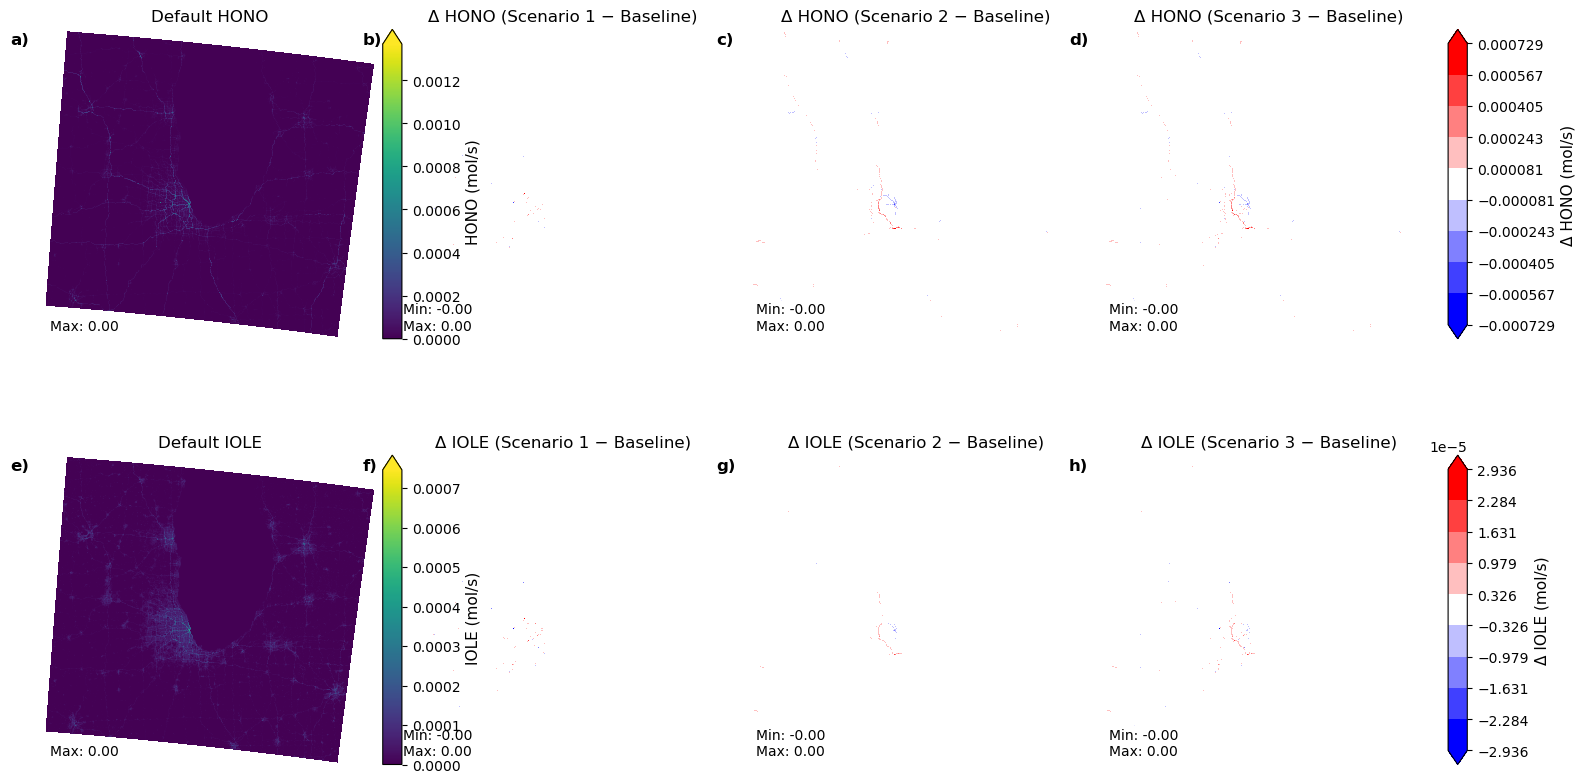

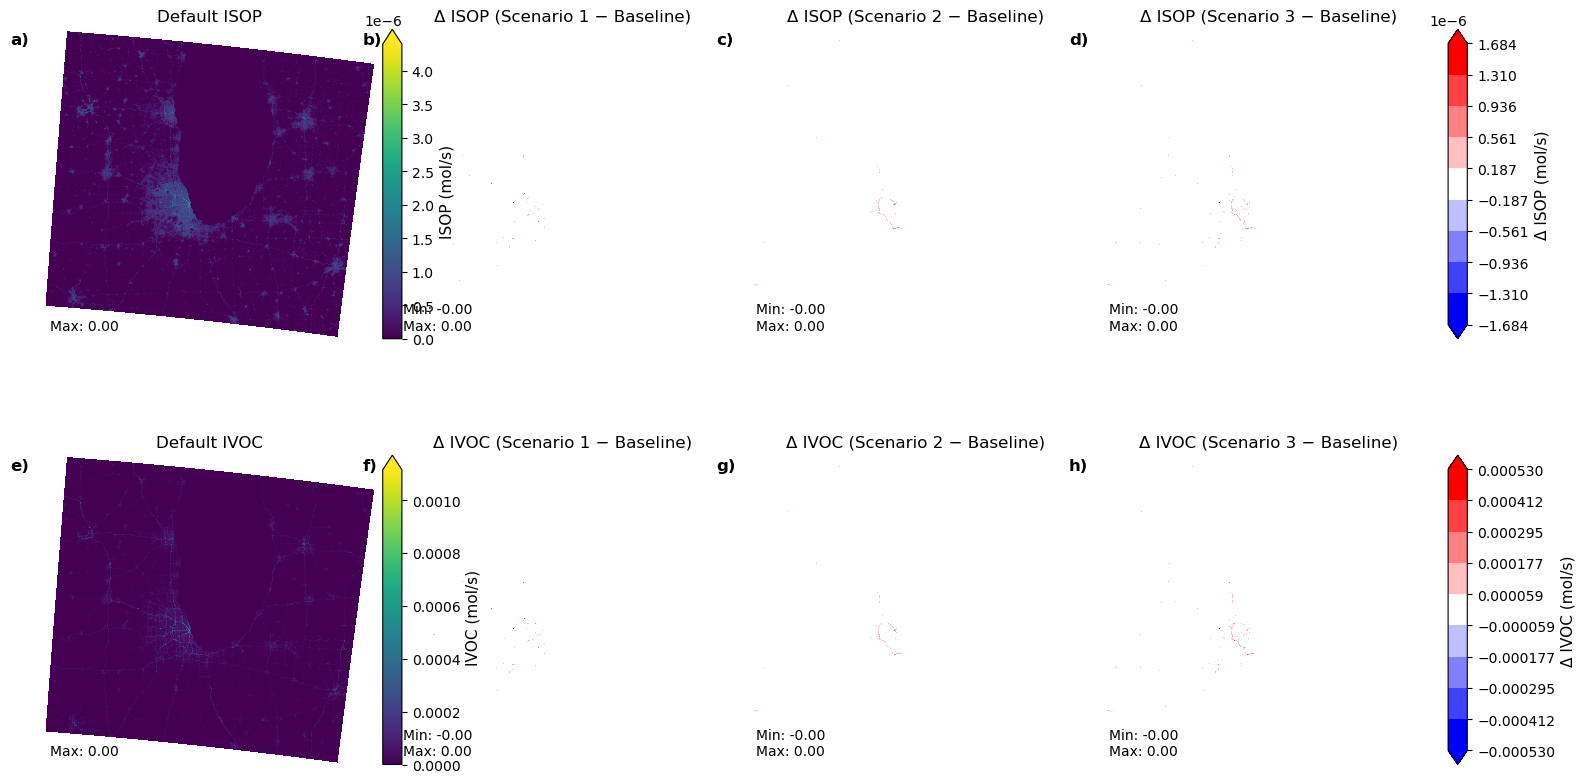

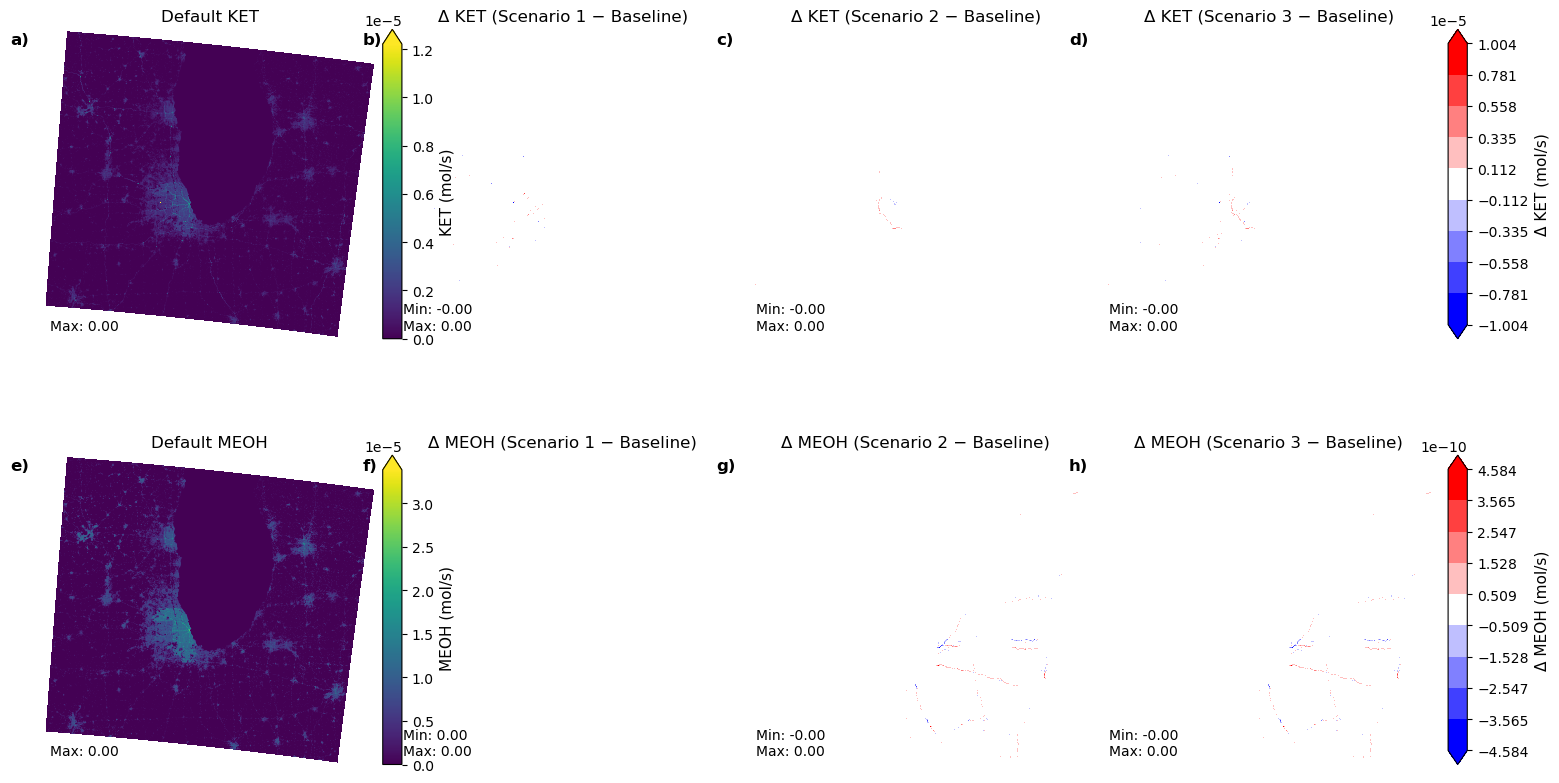

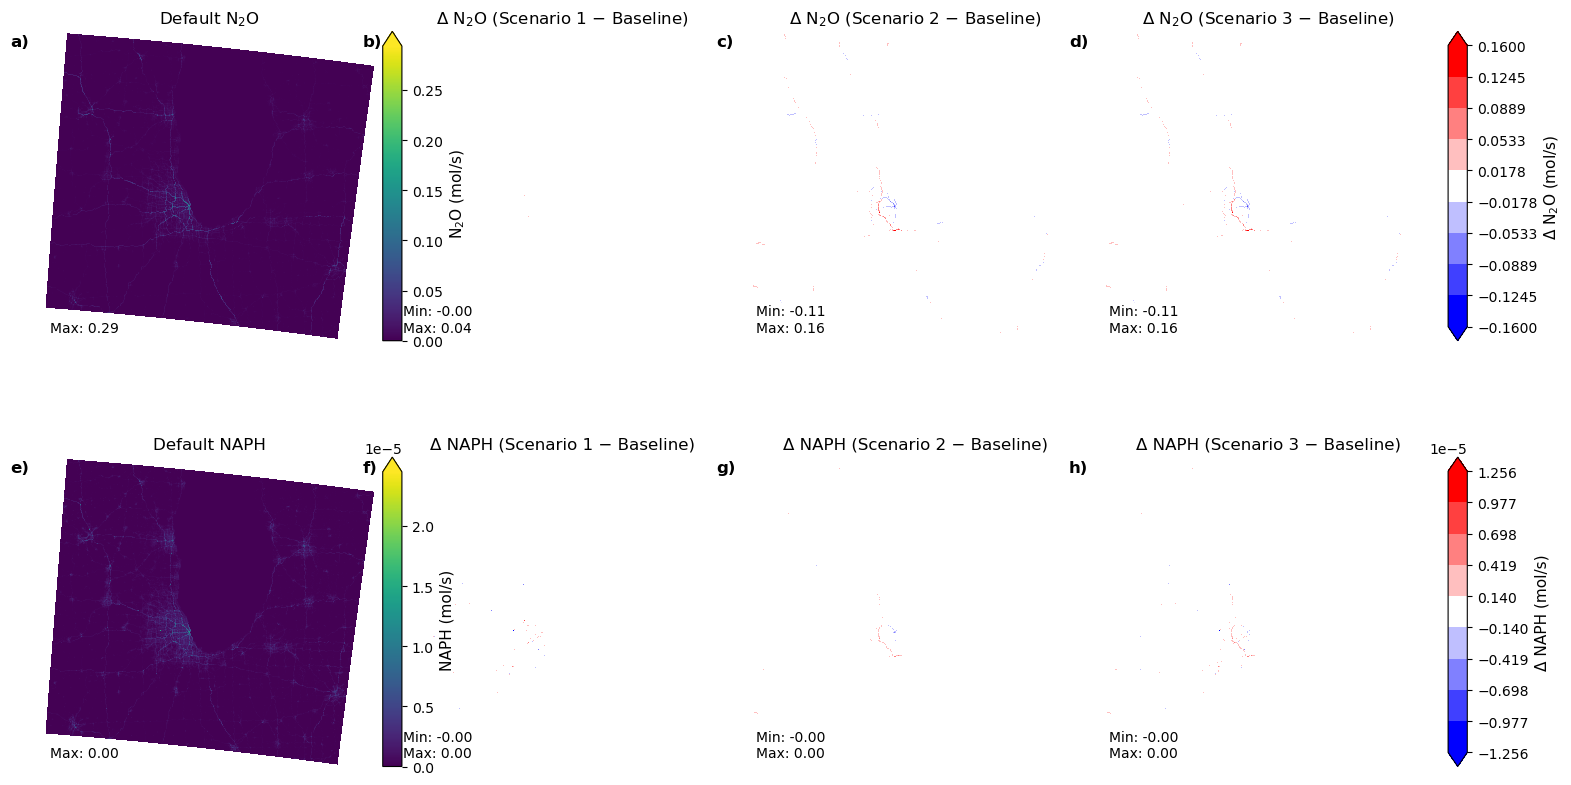

In [ ]:
# ============================================================
# FIND ALL SHARED NUMERIC COLUMNS
# ============================================================
all_vars = []

for col in base.columns:
    if col in exclude_cols:
        continue
    if not np.issubdtype(base[col].dtype, np.number):
        continue
    if col not in locus.columns:
        continue
    if col not in hdvspatial.columns:
        continue
    if col not in locus_hdvspatial.columns:
        continue
    all_vars.append(col)

print("Columns being plotted:")
for col in all_vars:
    print(col)

# ============================================================
# PLOT TWO VARIABLES PER FIGURE (2 ROWS x 4 COLS)
# ============================================================
for fig_idx in range(0, len(all_vars), 2):

    pair = all_vars[fig_idx:fig_idx+2]
    if len(pair) == 1:
        pair.append(None)

    fig, axs = plt.subplots(
        nrows=2, ncols=4, figsize=(16, 8.5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    panel_letters = list(string.ascii_lowercase)
    row_colorbar_info = []

    for row_i, col in enumerate(pair):

        if col is None:
            for j in range(4):
                axs[row_i, j].set_axis_off()
            continue

        species_label = nice_label(col)
        species_units = units_label(col)

        # --------------------------------------------------
        # BASELINE SCALE
        # --------------------------------------------------
        base_vals = base[col].astype(float).to_numpy()
        base_vals = base_vals[np.isfinite(base_vals)]

        ABS_VMIN = float(np.min(base_vals)) if base_vals.size else 0.0
        ABS_VMAX = float(np.max(base_vals)) if base_vals.size else 1.0

        if ABS_VMIN == ABS_VMAX:
            ABS_VMAX = ABS_VMIN + 1e-12

        cmap_abs = plt.cm.viridis
        norm_abs = mcolors.Normalize(vmin=ABS_VMIN, vmax=ABS_VMAX)

        # --------------------------------------------------
        # DIFFERENCE SCALE SHARED WITHIN VARIABLE
        # --------------------------------------------------
        diff1 = locus[col].astype(float).to_numpy() - base[col].astype(float).to_numpy()
        diff2 = hdvspatial[col].astype(float).to_numpy() - base[col].astype(float).to_numpy()
        diff3 = locus_hdvspatial[col].astype(float).to_numpy() - base[col].astype(float).to_numpy()

        all_diff = np.concatenate([diff1, diff2, diff3])
        all_diff = all_diff[np.isfinite(all_diff)]

        if all_diff.size == 0:
            DIFF_MAX = 1.0
        else:
            DIFF_MAX = float(np.max(np.abs(all_diff)))
            if DIFF_MAX == 0:
                DIFF_MAX = 1.0

        DIFF_MIN = -DIFF_MAX

        cmap_diff, norm_diff, diff_bounds = make_discrete_diff_cmap_and_norm(
            DIFF_MIN, DIFF_MAX, n_bins=9, cmap_name="bwr"
        )

        # --------------------------------------------------
        # PANEL LABELS
        # --------------------------------------------------
        letter_base = panel_letters[row_i * 4 + 0] + ")"
        letter_s1   = panel_letters[row_i * 4 + 1] + ")"
        letter_s2   = panel_letters[row_i * 4 + 2] + ")"
        letter_s3   = panel_letters[row_i * 4 + 3] + ")"

        # --------------------------------------------------
        # PLOT PANELS
        # --------------------------------------------------
        plot_gdf_column(
            axs[row_i, 0], base, col,
            cmap_abs, norm_abs, ABS_VMIN, ABS_VMAX,
            f"Default {species_label}",
            ann="max", label=letter_base
        )

        plot_array_panel(
            axs[row_i, 1], base, diff1,
            cmap_diff, norm_diff, DIFF_MIN, DIFF_MAX,
            f"Δ {species_label} (Scenario 1 − Baseline)",
            ann="minmax", label=letter_s1
        )

        plot_array_panel(
            axs[row_i, 2], base, diff2,
            cmap_diff, norm_diff, DIFF_MIN, DIFF_MAX,
            f"Δ {species_label} (Scenario 2 − Baseline)",
            ann="minmax", label=letter_s2
        )

        plot_array_panel(
            axs[row_i, 3], base, diff3,
            cmap_diff, norm_diff, DIFF_MIN, DIFF_MAX,
            f"Δ {species_label} (Scenario 3 − Baseline)",
            ann="minmax", label=letter_s3
        )

        row_colorbar_info.append({
            "row_i": row_i,
            "species_label": species_label,
            "species_units": species_units,
            "norm_abs": norm_abs,
            "cmap_abs": cmap_abs,
            "norm_diff": norm_diff,
            "cmap_diff": cmap_diff,
            "diff_bounds": diff_bounds
        })

    # ------------------------------------------------------
    # FINALIZE LAYOUT BEFORE COLORBARS
    # ------------------------------------------------------
    plt.tight_layout()
    fig.subplots_adjust(left=0.03, right=0.90, wspace=0.06, hspace=0.08)
    fig.canvas.draw()

    # ------------------------------------------------------
    # ADD COLORBARS
    # ------------------------------------------------------
    for info in row_colorbar_info:
        row_i = info["row_i"]

        pos_col1 = axs[row_i, 0].get_position()
        pos_col4 = axs[row_i, 3].get_position()

        cax_abs = fig.add_axes([
            pos_col1.x1 + 0.004,
            pos_col1.y0,
            0.012,
            pos_col1.height
        ])

        cax_diff = fig.add_axes([
            pos_col4.x1 + 0.008,
            pos_col4.y0,
            0.012,
            pos_col4.height
        ])

        cb_abs = fig.colorbar(
            plt.cm.ScalarMappable(norm=info["norm_abs"], cmap=info["cmap_abs"]),
            cax=cax_abs,
            extend="max"
        )
        cb_abs.set_label(f"{info['species_label']} ({info['species_units']})", fontsize=11)

        cb_diff = fig.colorbar(
            plt.cm.ScalarMappable(norm=info["norm_diff"], cmap=info["cmap_diff"]),
            cax=cax_diff,
            boundaries=info["diff_bounds"],
            ticks=info["diff_bounds"],
            spacing="proportional",
            extend="both"
        )
        cb_diff.set_label(f"Δ {info['species_label']} ({info['species_units']})", fontsize=11)

    # ------------------------------------------------------
    # SAVE
    # ------------------------------------------------------
    start_var = pair[0] if pair[0] is not None else "NA"
    end_var   = pair[1] if pair[1] is not None else "NA"

    fname = f"{fig_idx//2 + 1:02d}_{start_var}_to_{end_var}.png"
    fpath = os.path.join(outdir, fname)

    plt.savefig(fpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Done. All figures saved to: {outdir}")